<a href="https://colab.research.google.com/github/chintugani269-boop/Customer-Churn-Analysis/blob/main/Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Customer_churn.csv.txt")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [53]:
df.describe().sum()

,0
SeniorCitizen,7033.531244
tenure,7254.967046
MonthlyCharges,7459.684182
TotalCharges,25879.334303


In [54]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [55]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [56]:
df = df.dropna()

In [57]:
df.shape

(7032, 22)

**Churn Distribution**

In [58]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [59]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


**Churn Visualization**

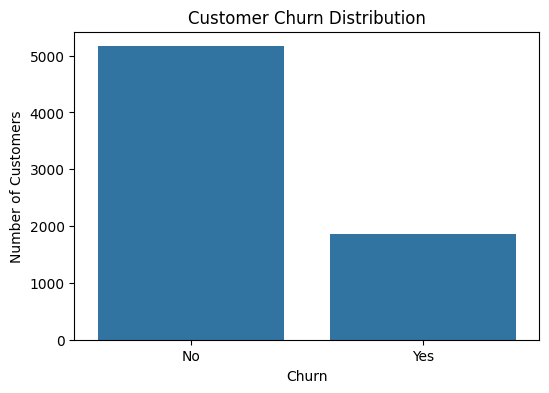

In [60]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

**Churn Percentage**

In [38]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


**Pie Chart**

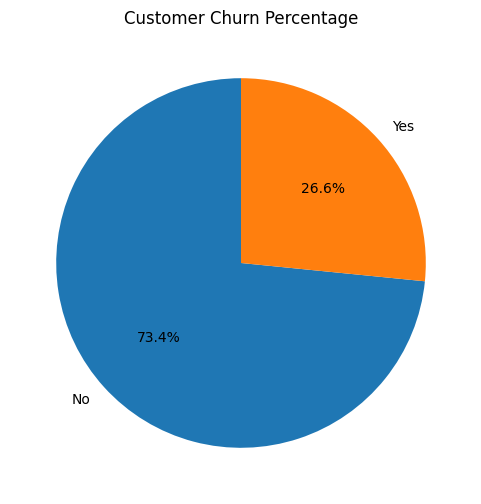

In [61]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customer Churn Percentage')

plt.show()

**Gender vs Churn**

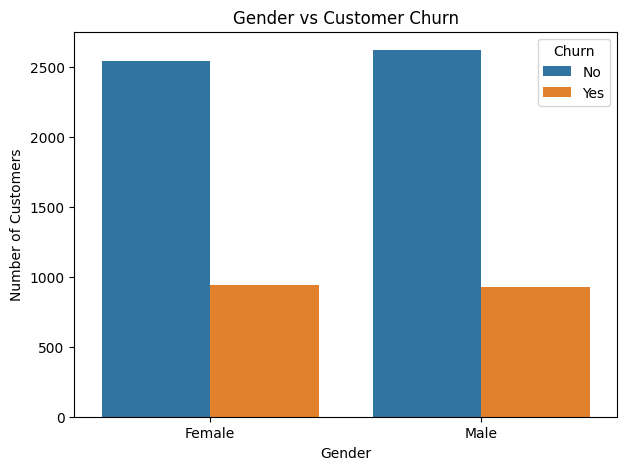

In [40]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

In [52]:
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"]
)

print(gender_churn)

Churn     No  Yes
gender           
Female  2544  939
Male    2619  930


**Contract vs Churn**

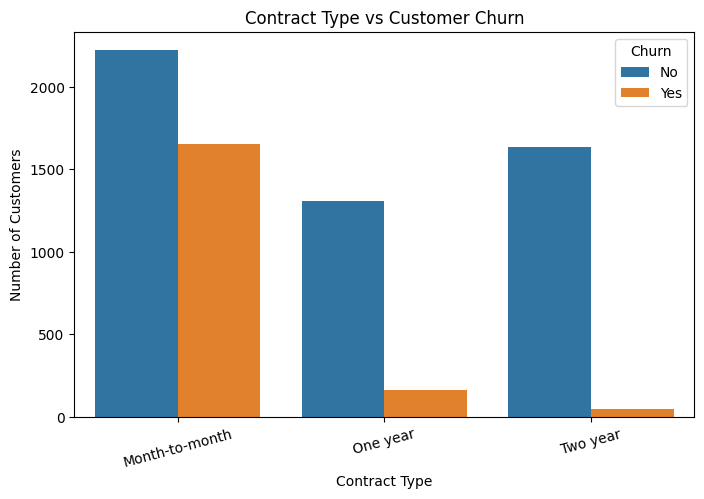

In [62]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

**Tenure vs Churn**

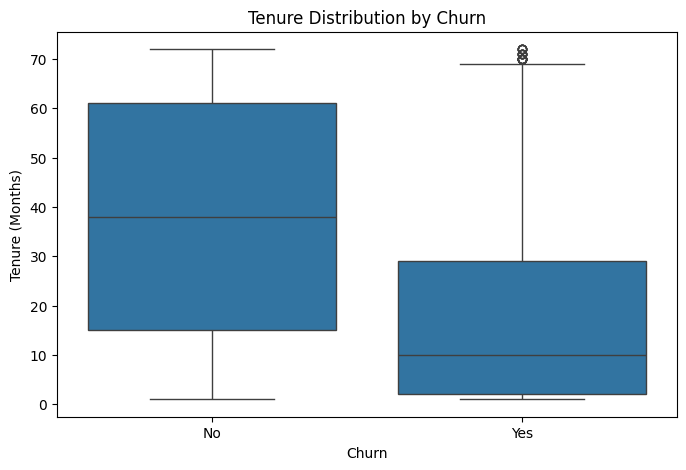

In [63]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Churn', y='tenure')

plt.title('Tenure Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()

**Monthly Charges vs Churn**

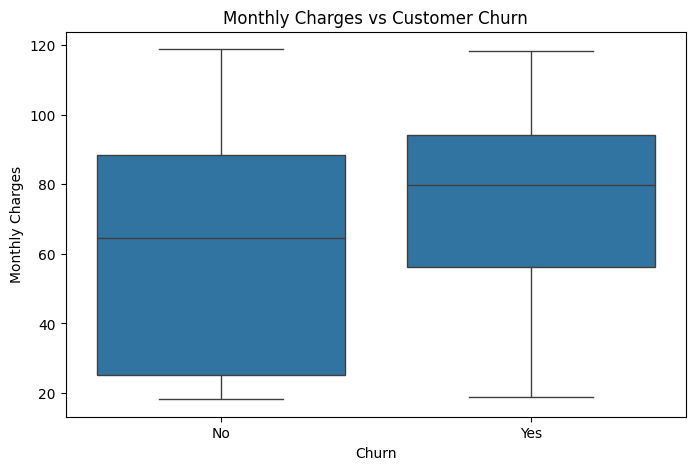

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

**Internet Service vs Churn**

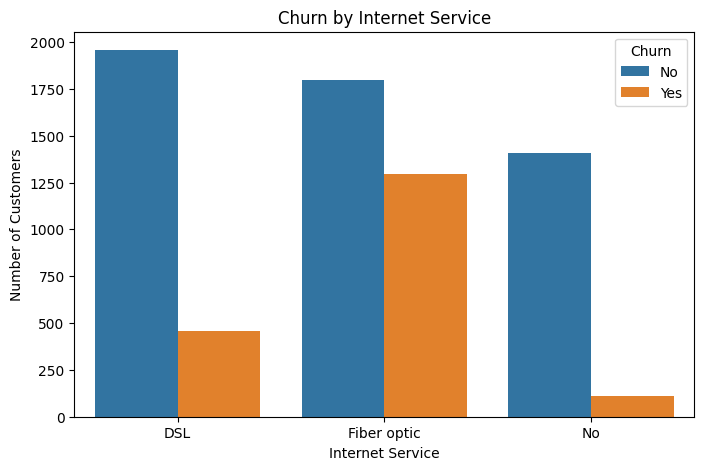

In [64]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='InternetService', hue='Churn')

plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.show()

**Payment Method vs Churn**

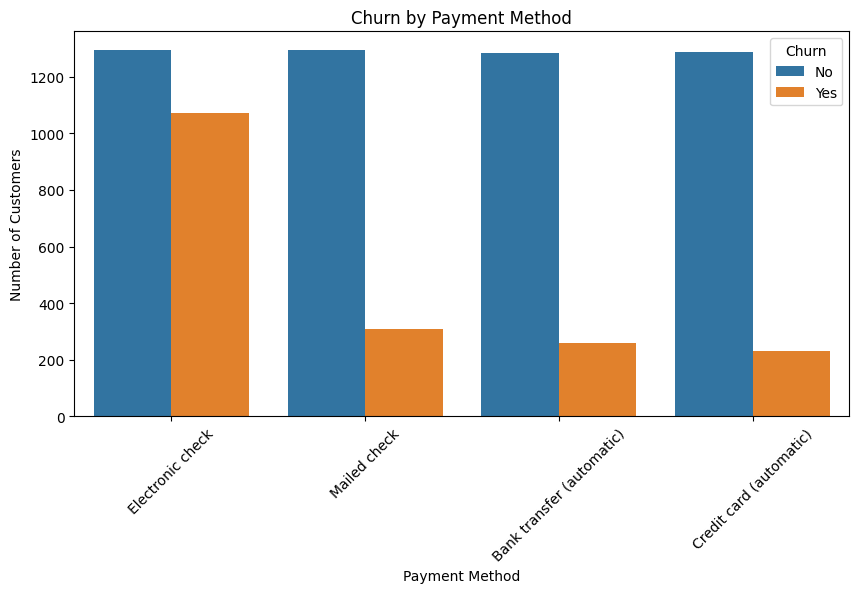

In [65]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x='PaymentMethod', hue='Churn')

plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45)

plt.show()

**Senior Citizen vs Churn**

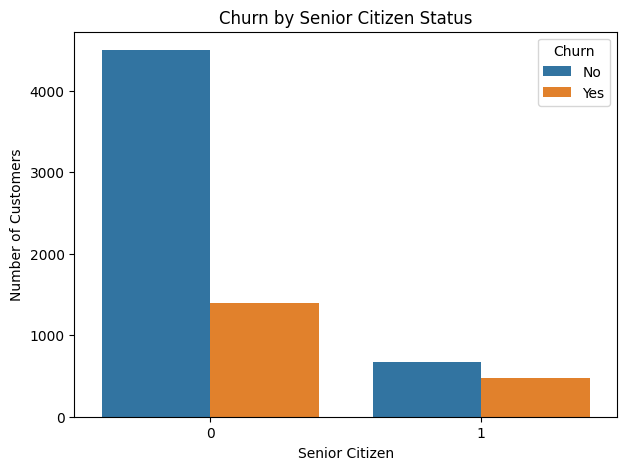

In [66]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='SeniorCitizen', hue='Churn')

plt.title('Churn by Senior Citizen Status')
plt.xlabel('Senior Citizen')
plt.ylabel('Number of Customers')

plt.show()

**Correlation Analysis**

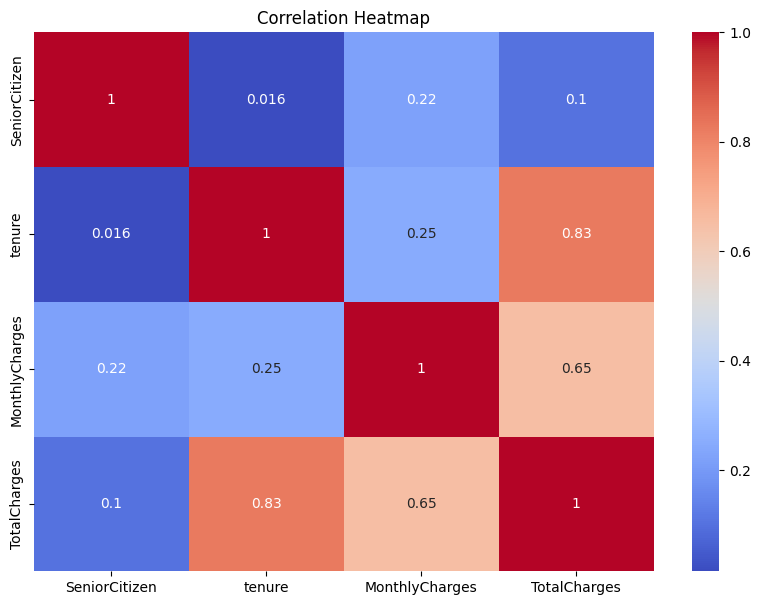

In [67]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

**Feature Engineering**

In [68]:
df_ml = df.copy()

df_ml.drop('customerID', axis=1, inplace=True)

**Convert Churn to Numeric**

In [69]:
df_ml['Churn'] = df_ml['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [70]:
df_ml['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


**One-Hot Encoding**

In [71]:
df_ml = pd.get_dummies(
    df_ml,
    drop_first=True
)

In [72]:
df_ml.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_13-24 Months,TenureGroup_25-48 Months,TenureGroup_49-72 Months
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,True,False,True,False,False,False,False


**Separate X and y**

In [73]:
X = df_ml.drop('Churn', axis=1)

y = df_ml['Churn']

In [74]:
X.shape

(7032, 33)

In [75]:
y.shape

(7032,)

**Train/Test Split**

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Logistic Regression**

In [78]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [79]:
y_pred_log = log_model.predict(X_test)

**Logistic Regression Evaluation**

In [80]:
from sklearn.metrics import accuracy_score

accuracy_log = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:",
      accuracy_log)

Logistic Regression Accuracy: 0.7945984363894811


**Classification Report**

In [81]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.52      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407



**Confusion Matrix**

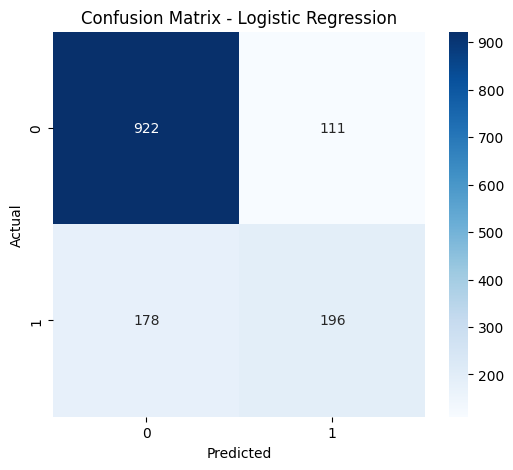

In [82]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

**Random Forest**

In [83]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [84]:
y_pred_rf = rf_model.predict(X_test)

**Random Forest Accuracy**

In [85]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:",
      accuracy_rf)

Random Forest Accuracy: 0.7860696517412935


**Compare Models**

In [86]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_log,
        accuracy_rf
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.794598
1,Random Forest,0.786070


In [87]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

plt.show()